## Wstęp do Uczenia Maszynowego - Projekt I
### Etap: Kamień Milowy III
### Autorzy: Krzysztof Osiński, Jakub Miszczak

## Import packages 

In [12]:
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(23)
import zipfile

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, f1_score,  precision_score, recall_score, precision_recall_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression


## Load data

In [2]:
zip_path = "fraud-detection-transactions-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open("synthetic_fraud_dataset.csv") as file:
        df = pd.read_csv(file)

df.columns = df.columns.str.replace(" ","_").str.lower()
df1 = df.drop(['transaction_id','user_id'],axis='columns')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

X = df1.drop('fraud_label', axis='columns')
Y = df1['fraud_label']

scaled_columns = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[scaled_columns] = scaler.fit_transform(X[scaled_columns])

## Przypomnienie wyników z kamienia milowego II:

Dzięki analizie i procesowi inżynierii cech w trakcie kamieni milowych I i II doszliśmy do wniosku, że większość cech nie ma potencjału predykcyjnego, lecz może wprowadzić niepotrzebny szum, więc skupiliśmy się na najważniejszych zmiennych.
Ostatecznie postanowiliśmy zachować następujące cechy: 
- failed_transaction_count_7d,
- risk_score, 
- failed_tx_risk_interaction,
- failed_tx_ratio
- amount_risk_interaction.

In [3]:
X['failed_tx_risk_interaction'] = X['failed_transaction_count_7d'] * X['risk_score']
X['failed_tx_ratio'] = X['failed_transaction_count_7d'] / (X['daily_transaction_count'] + 1)
X['amount_risk_interaction'] = X['transaction_amount'] * X['risk_score']

# Wybrane cechy
selected_features = [
    'failed_tx_ratio',
    'failed_tx_risk_interaction',
    'failed_transaction_count_7d',
    'risk_score',
    'amount_risk_interaction'
]

X_selected = X[selected_features]

In [4]:
print(f'Finalny kształt danych: {X_selected.shape}')
X_selected.head()

Finalny kształt danych: (50000, 5)


,failed_tx_ratio,failed_tx_risk_interaction,failed_transaction_count_7d,risk_score,amount_risk_interaction
0,0.513158,0.637039,0.75,0.849385,0.028784
1,0.520000,0.095810,1.00,0.095810,0.000097
2,0.500000,0.839984,1.00,0.839984,0.020718
3,0.650000,0.793479,1.00,0.793479,0.171868
4,0.500000,0.381838,1.00,0.381838,0.010172


## Dobór metryk do oceny modelu 
Oczywiście sprawdzimy accuracy, jednak skoro mówimy o detekcji fraudów, to warto spojrzeć również na Recall (czy model wykrywa wszystkie fraudy), który przy realym wyłapywaniu podejrzanych transakcji mógłby być bardziej istotny niż sama dokładność. Z drugiej strony istotne będzie także Precision (czy model nie robi fałszywych alarmów). Poza tym obliczymy F1-Score i AUC ROC.

## Podział danych

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y, test_size=0.2, stratify=Y, random_state=42)

# Wstępne testowanie różnych modeli
Przetestujmy różne modele i zobaczmy, które sprawdzają się najlepiej.

### Funkcja do ewaluacji modeli

In [6]:
def model_evaluation(y_true,y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"Accuracy score: {acc:.4f}")
    print(f"Precision score: {prec:.4f}")
    print(f"Recall score: {rec:.4f}")
    print(f"F1 score: {f1:.4f}")
    
    cm=confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], 
                yticklabels=["Actual 0", "Actual 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

### Trening

XGB
Model: XGB
Accuracy score: 0.9989
Precision score: 0.9982
Recall score: 0.9982
F1 score: 0.9982


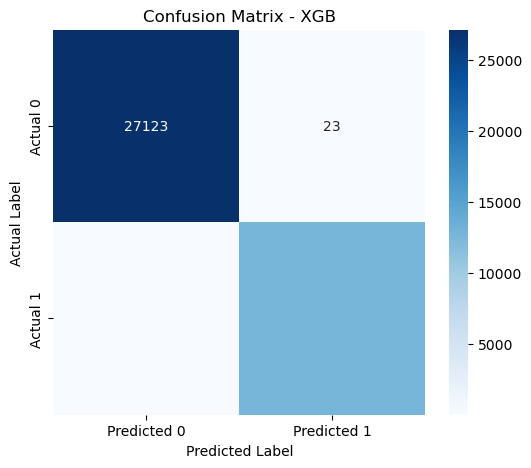

LightGBM
Model: LightGBM
Accuracy score: 0.9990
Precision score: 0.9982
Recall score: 0.9986
F1 score: 0.9984


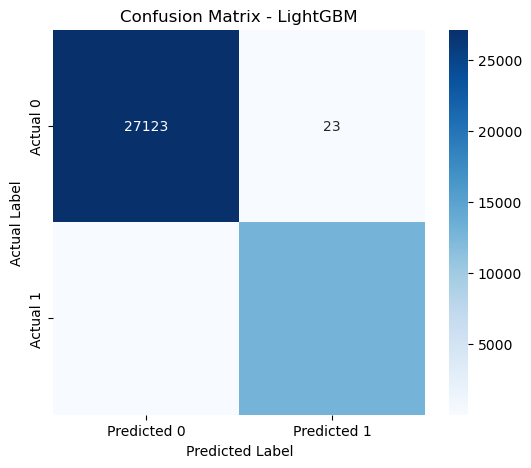

CatBoost
Model: CatBoost
Accuracy score: 0.9990
Precision score: 0.9986
Recall score: 0.9984
F1 score: 0.9985


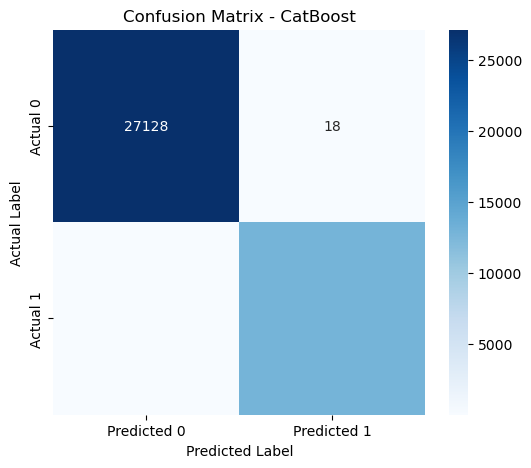

RandomForest
Model: RandomForest
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


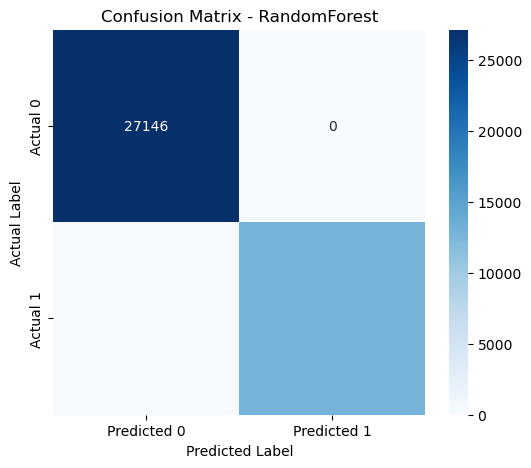

AdaBoost
Model: AdaBoost
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


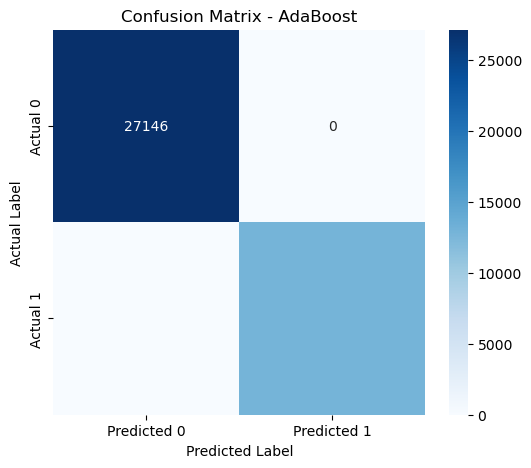

GradientBoosting
Model: GradientBoosting
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


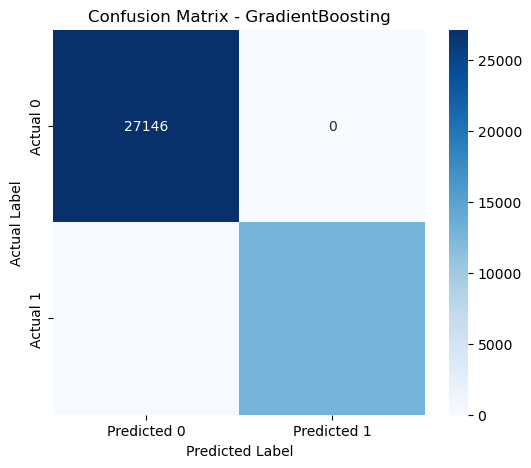

LogisticRegression
Model: LogisticRegression
Accuracy score: 0.9599
Precision score: 0.9107
Recall score: 0.9704
F1 score: 0.9396


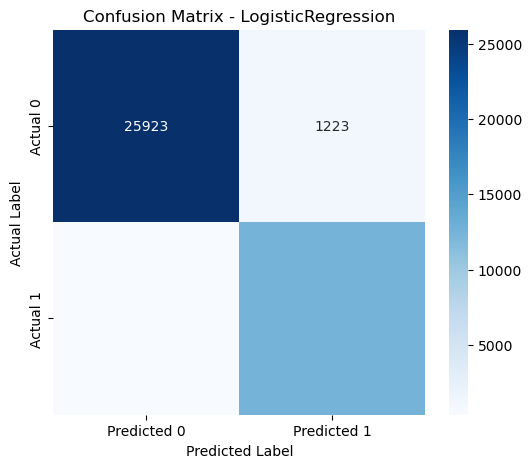

In [14]:
xgb_clf = XGBClassifier(verbosity=0)
lgbm_clf = LGBMClassifier(verbose=-1)
catboost_clf = CatBoostClassifier(verbose=0)
rf_clf = RandomForestClassifier()
adaboost_clf = AdaBoostClassifier()
gradient_clf = GradientBoostingClassifier(verbose=0)
logistic_reg = LogisticRegression()

estimators={
    'XGB':xgb_clf,
    'LightGBM': lgbm_clf,
    'CatBoost': catboost_clf,
    'RandomForest': rf_clf,
    'AdaBoost': adaboost_clf,
    'GradientBoosting': gradient_clf,
    'LogisticRegression': logistic_reg
}
models={}
for name, estimator in estimators.items():
    models[f'{name}']=estimator

for name, model in models.items():
    print(name)
    preds=cross_val_predict(model,X_train, y_train, cv=5)
    model_evaluation(y_train, preds, name)

# Dostrajanie parametrów
Postarajmy się znaleźć optymalne parametry modelu.

In [18]:
# Funkcja do strojenia hiperparametrów modelu za pomocą GridSearchCV

def tune_model(model, param_grid, X_train, y_train, cv=5, scoring='roc_auc', verbose=2):
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        verbose=verbose,
        n_jobs=-1
    )
    
    print(f"🔍 Start GridSearchCV dla {model.__class__.__name__}...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n✅ Najlepsze parametry: {grid_search.best_params_}")
    print(f"🏆 Najlepszy wynik ({scoring}): {grid_search.best_score_:.4f}")
    
    return grid_search

# 1. Random Forest

## Random Search

In [28]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=None, bootstrap=True)

param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': [None] + list(np.arange(5, 50, 5)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,                # liczba losowań kombinacji
    cv=5,                     # 5-krotna kroswalidacja
    scoring='roc_auc',        # lub inna metryka
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Najlepsze parametry:", random_search.best_params_)
print("Najlepsze ROC AUC:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Najlepsze parametry: {'n_estimators': 900, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 40, 'bootstrap': True}
Najlepsze ROC AUC: 1.0


## Grid Search

In [19]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=None, bootstrap=True)

param_grid_rf = {
    'n_estimators': [850, 900, 950],
    'max_depth': [38, 40, 42]
}

grid_search_rf = tune_model(rf, param_grid_rf, X_train, y_train)

🔍 Start GridSearchCV dla RandomForestClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Najlepsze parametry: {'max_depth': 38, 'n_estimators': 850}
🏆 Najlepszy wynik (roc_auc): 1.0000


# 2. XGBoost

In [20]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = tune_model(xgb, param_grid_xgb, X_train, y_train)

🔍 Start GridSearchCV dla XGBClassifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Najlepsze parametry: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
🏆 Najlepszy wynik (roc_auc): 1.0000


# 3. AdaBoost

In [21]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

param_grid_ada = {
    'n_estimators': [50, 100, 300],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_search_ada = tune_model(ada, param_grid_ada, X_train, y_train)

🔍 Start GridSearchCV dla AdaBoostClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Najlepsze parametry: {'learning_rate': 0.01, 'n_estimators': 50}
🏆 Najlepszy wynik (roc_auc): 0.9999


# 4. Gradient Boosting

In [22]:
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_search_gbc = tune_model(gbc, param_grid_gbc, X_train, y_train)

🔍 Start GridSearchCV dla GradientBoostingClassifier...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Najlepsze parametry: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
🏆 Najlepszy wynik (roc_auc): 0.9999


# Finalne Modele

Model: XGBoostClassifier
Accuracy score: 0.9990
Precision score: 0.9987
Recall score: 0.9982
F1 score: 0.9984


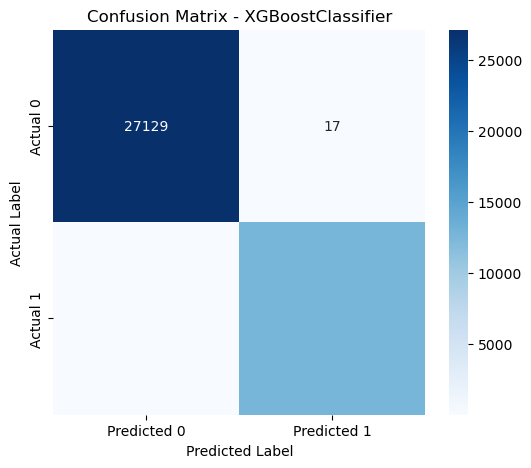

In [25]:
xgb_final_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, colsample_bytree=1.0,
                    learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0)
                    
xgb_preds = cross_val_predict(xgb_final_model, X_train, y_train, cv=5)
model_evaluation(y_train, xgb_preds, 'XGBoostClassifier')

Model: RandomForestClassifier
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 0.9998
F1 score: 0.9999


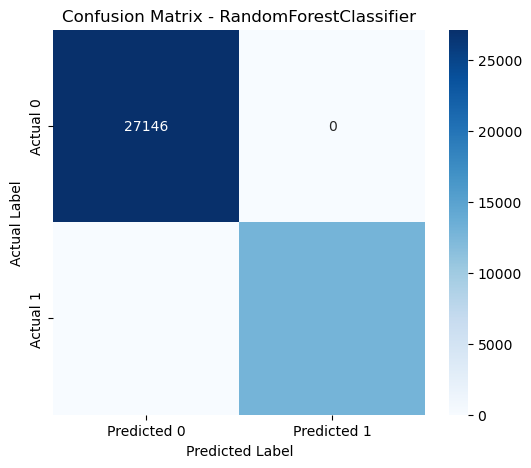

In [26]:
rf_final_model = RandomForestClassifier(random_state=42, n_estimators=850, min_samples_split=10, min_samples_leaf=4, 
                               max_depth=38, max_features=None, bootstrap=True)

rf_preds = cross_val_predict(rf_final_model, X_train, y_train, cv=5)
model_evaluation(y_train, rf_preds, 'RandomForestClassifier')

# Test odporności na szum w danych

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def add_noise(X, noise_level=0.01, seed=42):

    np.random.seed(seed)
    X_noisy = X.copy()
    numeric_cols = X_noisy.select_dtypes(include=np.number).columns
    
    for col in numeric_cols:
        noise = np.random.normal(0, noise_level, size=X_noisy.shape[0])
        X_noisy[col] += noise
    
    return X_noisy

def test_model_robustness_plot(model, X_test, y_test, model_name="Model", noise_levels=[0.0, 0.01, 0.05, 0.1]):

    print(f"\n Test odporności dla: {model_name}")

    roc_auc_scores = []
    
    for noise in noise_levels:
        if noise == 0:
            X_mod = X_test.copy()
        else:
            X_mod = add_noise(X_test, noise_level=noise)
        
        y_pred_proba = model.predict_proba(X_mod)[:,1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        roc_auc_scores.append(roc_auc)
        
        print(f"Noise Level {noise:.2f} -> ROC AUC: {roc_auc:.4f}")
    
    # Wykres
    plt.figure(figsize=(8, 5))
    plt.plot(noise_levels, roc_auc_scores, marker='o')
    plt.title(f"Robustness Test - {model_name}")
    plt.xlabel("Poziom szumu (noise level)")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.ylim(0.0, 1.05)
    plt.show()



🚀 Test odporności dla: Random Forest
Noise Level 0.00 -> ROC AUC: 1.0000
Noise Level 0.01 -> ROC AUC: 0.9917
Noise Level 0.05 -> ROC AUC: 0.9616
Noise Level 0.10 -> ROC AUC: 0.8909


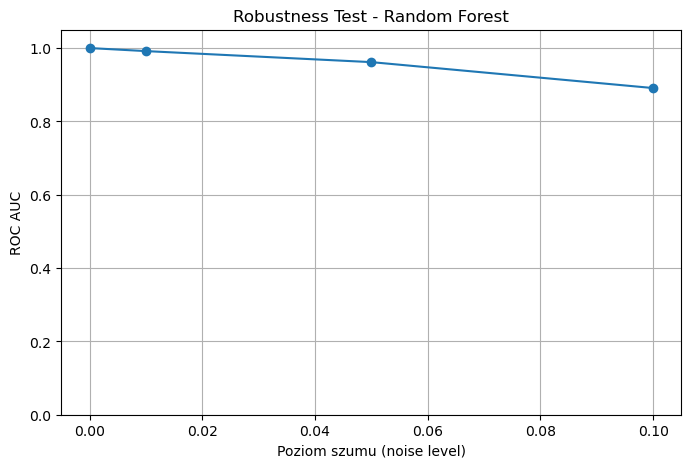


🚀 Test odporności dla: XGBoost
Noise Level 0.00 -> ROC AUC: 1.0000
Noise Level 0.01 -> ROC AUC: 0.9562
Noise Level 0.05 -> ROC AUC: 0.9297
Noise Level 0.10 -> ROC AUC: 0.8859


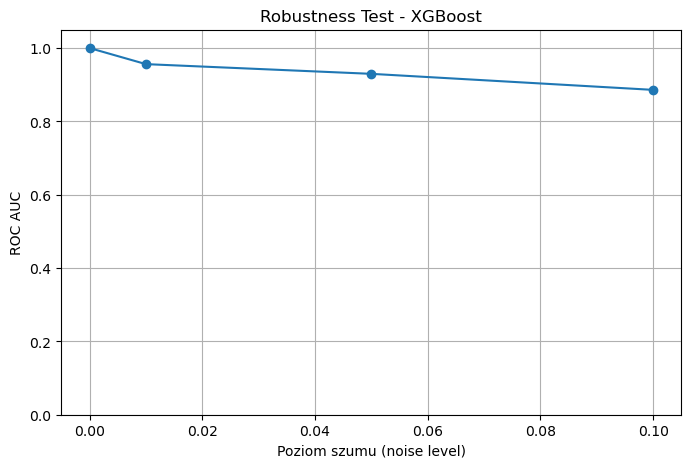

In [31]:
rf_final_model.fit(X_train, y_train)
test_model_robustness_plot(rf_final_model, X_test, y_test, model_name="Random Forest")

xgb_final_model.fit(X_train, y_train)
test_model_robustness_plot(xgb_final_model, X_test, y_test, model_name="XGBoost")

# Wybór
Finalnie wybraliśmy Random Forest.

# Testowanie modelu
Ewaluacja modelu na bazie danych walidacyjnych (ok. 20% zbioru danych, na którym nie był trenowany model).

CPU times: total: 24.5 s
Wall time: 25.2 s
Model: RandomForestClasiffier
Accuracy score: 1.0000
Precision score: 1.0000
Recall score: 1.0000
F1 score: 1.0000


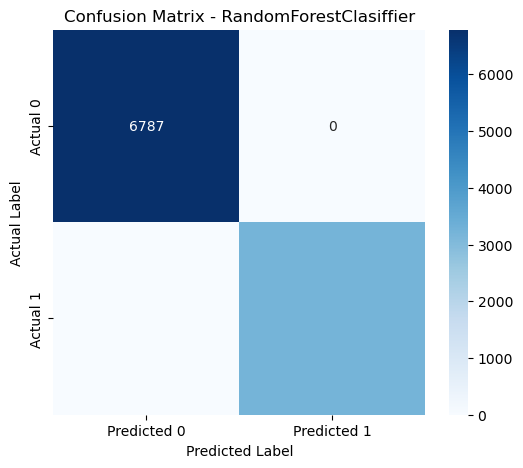

In [16]:
model = RandomForestClassifier(random_state=42, n_estimators=850, min_samples_split=10, min_samples_leaf=4, 
                               max_depth=38, max_features=None, bootstrap=True)
%time model.fit(X_train,y_train)
preds=model.predict(X_test)
model_evaluation(y_test, preds, 'RandomForestClasiffier')

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Wyniki
Model osiągnął bardzo dobre wyniki zmierzone metrykami dobranymi dla naszego problemu. 